# Week 2 — California single-family sales exploration

This notebook explores six consecutive CRMLS sold-data files, January through June 2024. The analysis is limited to California records with `PropertyType == Residential` and `PropertySubType == SingleFamilyResidence`, and to close dates within those six months. It describes sold homes; it does not train a model or measure off-market accuracy.

The raw CSV files are expected in `csv/` and are not committed to Git. Only the columns needed for this exploration are loaded. `ListingKey` is used only to remove duplicate sale records, never as a valuation feature.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path('csv')
if not DATA_DIR.is_dir():
    raise FileNotFoundError('Place the CRMLS sold CSV files in the repository csv/ directory.')

months = pd.period_range('2024-01', '2024-06', freq='M')
files = []
for month in months:
    matches = sorted(DATA_DIR.glob(f'CRMLSSold{month.year}{month.month:02d}*.csv'))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected one sold CSV for {month}; found {len(matches)}.')
    files.append(matches[0])

columns = [
    'ListingKey', 'CloseDate', 'ClosePrice', 'PropertyType', 'PropertySubType',
    'StateOrProvince', 'LivingArea', 'BedroomsTotal',
    'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeAcres',
]
raw_sales = pd.concat(
    [pd.read_csv(path, usecols=columns, dtype={'ListingKey': 'string'}, low_memory=False) for path in files],
    ignore_index=True,
)
print(f'Loaded {len(raw_sales):,} records from {len(files)} monthly files.')
display(pd.DataFrame({'Source file': [path.name for path in files]}))

Loaded 136,614 records from 6 monthly files.


,Source file
0,CRMLSSold202401_filled.csv
1,CRMLSSold202402.csv
2,CRMLSSold202403_filled.csv
3,CRMLSSold202404_filled.csv
4,CRMLSSold202405_filled.csv
5,CRMLSSold202406_filled.csv


## Scope and preparation

The date and property-type filters define the EDA population. Duplicate nonmissing `ListingKey` values are removed after sorting by close date. Numeric parsing errors and impossible negative values become missing; zero bedrooms or bathrooms remain valid. Missing lot square footage is filled from positive lot acres when available (`1 acre = 43,560 square feet`). No price or size outlier is removed from the descriptive statistics.

In [2]:
scope_mask = (
    raw_sales['PropertyType'].eq('Residential')
    & raw_sales['PropertySubType'].eq('SingleFamilyResidence')
    & raw_sales['StateOrProvince'].astype('string').str.upper().eq('CA')
)
scoped_sales = raw_sales.loc[scope_mask].copy()
scoped_sales['CloseDate'] = pd.to_datetime(scoped_sales['CloseDate'], errors='coerce')
date_mask = scoped_sales['CloseDate'].ge('2024-01-01') & scoped_sales['CloseDate'].lt('2024-07-01')
dated_sales = scoped_sales.loc[date_mask].sort_values('CloseDate', kind='mergesort').copy()
has_key = dated_sales['ListingKey'].notna()
duplicate_keys_removed = int(dated_sales.loc[has_key, 'ListingKey'].duplicated().sum())
sales = pd.concat(
    [dated_sales.loc[has_key].drop_duplicates('ListingKey', keep='last'), dated_sales.loc[~has_key]],
    ignore_index=True,
).sort_values('CloseDate', kind='mergesort').reset_index(drop=True)

numeric_columns = [
    'ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
    'LotSizeSquareFeet', 'LotSizeAcres',
]
for column in numeric_columns:
    sales[column] = pd.to_numeric(sales[column], errors='coerce').replace([np.inf, -np.inf], np.nan)
for column in ['ClosePrice', 'LivingArea', 'LotSizeSquareFeet', 'LotSizeAcres']:
    sales[column] = sales[column].where(sales[column].gt(0))
for column in ['BedroomsTotal', 'BathroomsTotalInteger']:
    sales[column] = sales[column].where(sales[column].ge(0))
sales['LotSizeSqFt'] = sales['LotSizeSquareFeet'].fillna(sales['LotSizeAcres'] * 43_560)
sales = sales.rename(columns={'BedroomsTotal': 'Bedrooms', 'BathroomsTotalInteger': 'Bathrooms'})

audit = pd.Series({
    'Raw rows loaded': len(raw_sales),
    'California residential single-family rows': len(scoped_sales),
    'Rows with a January–June 2024 close date': len(dated_sales),
    'Duplicate listing keys removed': duplicate_keys_removed,
    'Final unique sales': len(sales),
}, name='Rows')
display(audit.to_frame())

,Rows
Raw rows loaded,136614
California residential single-family rows,68635
Rows with a January–June 2024 close date,68635
Duplicate listing keys removed,34
Final unique sales,68601


In [3]:
monthly_sales = sales.groupby(sales['CloseDate'].dt.to_period('M')).size().reindex(months, fill_value=0)
assert (monthly_sales > 0).all(), 'The filtered data must cover all six months.'
display(monthly_sales.rename('Unique sales').to_frame())

eda_columns = ['ClosePrice', 'LivingArea', 'Bedrooms', 'Bathrooms', 'LotSizeSqFt']
summary = sales[eda_columns].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary['missing_n'] = sales[eda_columns].isna().sum()
summary['missing_pct'] = sales[eda_columns].isna().mean() * 100
display(summary[['count', 'missing_n', 'missing_pct', 'mean', 'std', 'min', '5%', '25%', '50%', '75%', '95%', '99%', 'max']].round(1))

,Unique sales
2024-01,8321
2024-02,9564
2024-03,11633
2024-04,12729
2024-05,13809
2024-06,12545


,count,missing_n,missing_pct,mean,std,min,5%,25%,50%,75%,95%,99%,max
ClosePrice,68600.0,1,0.0,1257463.1,1.331017e+06,345.0,364000.0,615000.0,895694.0,1460000.0,3200000.0,5975200.0,6.280000e+07
LivingArea,68539.0,62,0.1,2028.0,1.027300e+03,100.0,960.0,1368.0,1798.0,2414.5,3810.0,5678.0,2.289700e+04
Bedrooms,68601.0,0,0.0,3.5,1.000000e+00,0.0,2.0,3.0,3.0,4.0,5.0,6.0,3.400000e+01
Bathrooms,68582.0,19,0.0,2.6,1.300000e+00,0.0,1.0,2.0,2.0,3.0,5.0,6.0,1.750000e+02
LotSizeSqFt,67401.0,1200,1.7,5255269.8,1.310595e+09,0.0,3264.0,5663.0,7221.0,10260.0,49223.0,245678.0,3.402340e+11


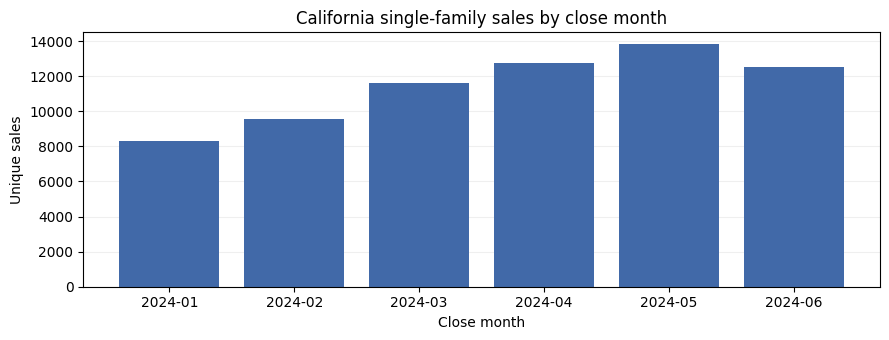

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(monthly_sales.index.astype(str), monthly_sales.values, color='#4169A8')
ax.set(title='California single-family sales by close month', xlabel='Close month', ylabel='Unique sales')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Distributions

The descriptive table above retains the full positive-value range. For readable linear-scale histograms, values above each variable's 99th percentile are omitted from that plot only. The second close-price histogram uses a log scale and includes all positive prices. The lot-size plot uses a log scale between the 1st and 99th percentiles. Bedroom and bathroom charts show 0–8; larger counts remain in the summary table.

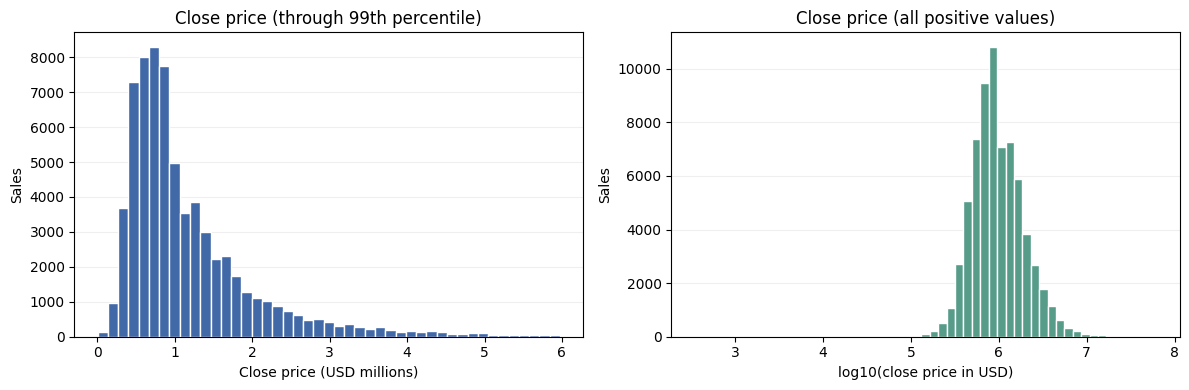

In [5]:
prices = sales['ClosePrice'].dropna()
price_p99 = prices.quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices.loc[prices.le(price_p99)] / 1_000_000, bins=45, color='#4169A8', edgecolor='white')
axes[0].set(title='Close price (through 99th percentile)', xlabel='Close price (USD millions)', ylabel='Sales')
axes[1].hist(np.log10(prices), bins=55, color='#569C89', edgecolor='white')
axes[1].set(title='Close price (all positive values)', xlabel='log10(close price in USD)', ylabel='Sales')
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

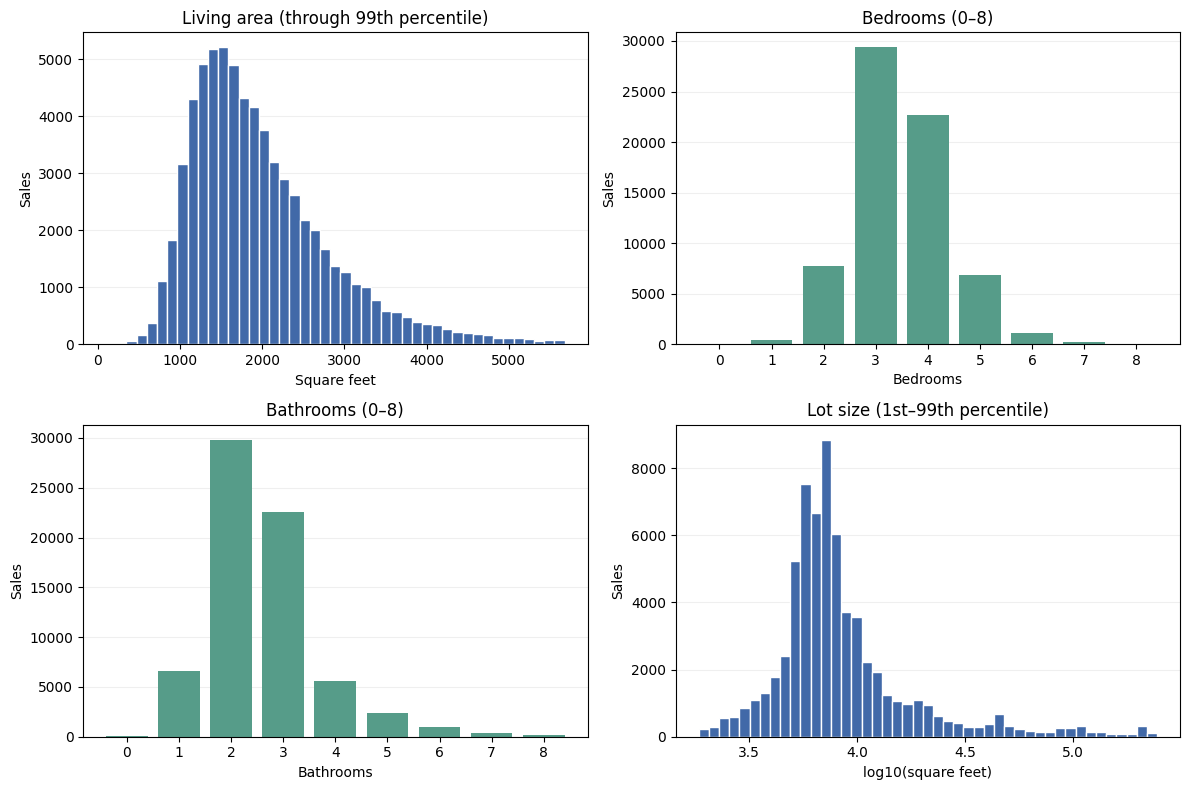

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
living_area = sales['LivingArea'].dropna()
living_area_cap = living_area.quantile(0.99)
axes[0, 0].hist(living_area.loc[living_area.le(living_area_cap)], bins=45, color='#4169A8', edgecolor='white')
axes[0, 0].set(title='Living area (through 99th percentile)', xlabel='Square feet', ylabel='Sales')
lot_size = sales['LotSizeSqFt'].dropna()
lot_low, lot_high = lot_size.quantile([0.01, 0.99])
lot_plot = lot_size.loc[lot_size.between(lot_low, lot_high)]
axes[1, 1].hist(np.log10(lot_plot), bins=45, color='#4169A8', edgecolor='white')
axes[1, 1].set(title='Lot size (1st–99th percentile)', xlabel='log10(square feet)', ylabel='Sales')
for ax, column, title in [
    (axes[0, 1], 'Bedrooms', 'Bedrooms (0–8)'),
    (axes[1, 0], 'Bathrooms', 'Bathrooms (0–8)'),
]:
    counts = sales.loc[sales[column].between(0, 8), column].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#569C89')
    ax.set(title=title, xlabel=column, ylabel='Sales')
    ax.set_xticks(counts.index)
for ax in axes.flat:
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Interpretation and limits

Use the summary quantiles and log-price chart to assess the long right tail. The extreme recorded bathroom and lot-size maxima suggest source-data errors, so the medians and quantiles are more informative than the means for those fields. Missing-value counts describe the five requested variables after the stated lot-size fallback. These MLS closed sales are a selected sample of homes that sold, not a representative sample of every off-market California address. No list price, days-on-market, or contract-date field is used in the analysis.